# P9a: PyTorch asoslari

Bu notebook bugungi deep learning practice uchun qisqa tayyorgarlik. Maqsad PyTorch'ni alohida, kichik misollarda ko'rish: tensor, autograd, `nn.Module`, `Dataset/DataLoader`, training loop va LSTM shape'lari.

Bu notebook `d10_p9_textgen`dan oldin ishlatilishi mumkin. Tashqi dataset kerak emas.


## 1. Muhit

Kaggle'da PyTorch odatda tayyor o'rnatilgan bo'ladi. GPU shart emas: bu notebookdagi misollar CPU'da ham tez ishlaydi.


In [75]:
import os
import sys
import random
import math
import tempfile
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))

import numpy as np

random.seed(42)
np.random.seed(42)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    torch.manual_seed(42)
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    torch = None
    nn = None
    Dataset = object
    DataLoader = None

HAS_MATPLOTLIB = None

print("Python:", sys.version.split()[0])
print("NumPy :", np.__version__)
print("Torch :", torch.__version__ if HAS_TORCH else "topilmadi")
print("Device:", "cuda" if HAS_TORCH and torch.cuda.is_available() else "cpu")


Python: 3.12.13
NumPy : 2.0.2
Torch : 2.10.0+cpu
Device: cpu


## 2. Tensor va shape

PyTorch tensorlari NumPy arraylariga o'xshaydi, lekin GPU va autograd bilan ishlaydi. Deep learningdagi ko'p xatolar shape noto'g'ri tushunilganidan keladi.


In [76]:
if HAS_TORCH:
    import torch

    x = torch.tensor([[1.0, 2.0, 3.0],
                      [4.0, 5.0, 6.0]])

    weights = torch.tensor([[0.2, -0.3],
                            [0.5,  0.1],
                            [0.7,  0.4]])

    # 1. Matrix multiplication
    logits = x @ weights

    # 2. Softmax dim=1 bo'yicha
    probabilities = torch.softmax(logits, dim=1)

    print("logits shape:", tuple(logits.shape))
    print("logits:\n", logits)

    print("probabilities:\n", probabilities)
else:
    print("Kaggle'da torch mavjud bo'ladi. Bu local muhitda torch yo'q.")


logits shape: (2, 2)
logits:
 tensor([[3.3000, 1.1000],
        [7.5000, 1.7000]])
probabilities:
 tensor([[0.9002, 0.0998],
        [0.9970, 0.0030]])


## 3. Autograd

`requires_grad=True` bo'lsa, PyTorch amallar grafigini eslab qoladi. `loss.backward()` chaqirilganda gradientlar `.grad` ichida paydo bo'ladi.


In [77]:
if HAS_TORCH:
    import torch

    w = torch.tensor(0.0, requires_grad=True)
    target = torch.tensor(3.0)

    loss = (w - target) ** 2
    loss.backward()

    print("loss:", loss.item())
    print("d loss / d w:", w.grad.item())
else:
    print("Autograd demo uchun torch kerak.")


loss: 9.0
d loss / d w: -6.0


## 4. Gradient descent qo'lda

Optimizer nima qilayotganini ko'rish uchun avval bitta parametrni qo'lda yangilaymiz.


In [78]:
if HAS_TORCH:
    import torch

    w = torch.tensor(0.0, requires_grad=True)
    lr = 0.2
    history = []

    for step in range(15):
        # 1. Loss hisoblash
        loss = (w - 3) ** 2

        # 2. Gradient hisoblash
        loss.backward()

        # 3. Parametrni yangilash
        with torch.no_grad():
            w -= lr * w.grad

        # 4. Gradientni tozalash
        w.grad.zero_()

        history.append(loss.item())

    print("w:", round(w.item(), 3))
    print("loss history:", history)
else:
    history = []
    print("Manual training demo uchun torch kerak.")


w: 2.999
loss history: [9.0, 3.239999771118164, 1.1663998365402222, 0.4199039936065674, 0.15116536617279053, 0.05441953241825104, 0.019591018557548523, 0.007052774541079998, 0.002539008390158415, 0.0009140430483967066, 0.00032905375701375306, 0.00011845728295156732, 4.264462040737271e-05, 1.5352063201135024e-05, 5.526294444280211e-06]


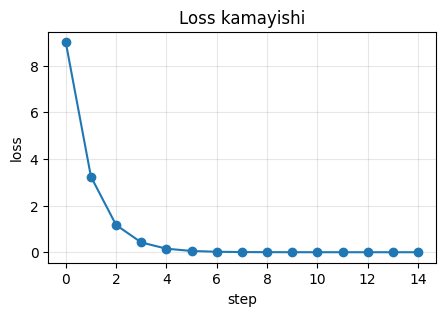

In [79]:
if history:
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(5, 3))
        plt.plot(history, marker="o")
        plt.title("Loss kamayishi")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.grid(True, alpha=0.3)
        plt.show()
    except ImportError:
        print("Loss history:", history)
else:
    print("Plot uchun training history yo'q.")


## 5. Kichik NLP dataset

Endi juda kichik sentiment dataset bilan `nn.Module` va training loop ko'ramiz. Bu katta model emas; maqsad PyTorch mexanikasini tushunish.


In [80]:
texts = [
    "mahsulot juda yaxshi",
    "xizmat ajoyib va tez",
    "taom mazali ekan",
    "telefon menga yoqdi",
    "yetkazish yomon bo'ldi",
    "mahsulot sifatsiz ekan",
    "xizmat juda sekin",
    "narxi qimmat va yomon",
]
labels = [1, 1, 1, 1, 0, 0, 0, 0]

vocab = sorted({token for text in texts for token in text.split()})
word_to_index = {word: index for index, word in enumerate(vocab)}

print("Vocab size:", len(vocab))
print(word_to_index)


Vocab size: 20
{'ajoyib': 0, "bo'ldi": 1, 'ekan': 2, 'juda': 3, 'mahsulot': 4, 'mazali': 5, 'menga': 6, 'narxi': 7, 'qimmat': 8, 'sekin': 9, 'sifatsiz': 10, 'taom': 11, 'telefon': 12, 'tez': 13, 'va': 14, 'xizmat': 15, 'yaxshi': 16, 'yetkazish': 17, 'yomon': 18, 'yoqdi': 19}


In [81]:
def vectorize(text):
    vector = np.zeros(len(vocab), dtype=np.float32)
    for token in text.split():
        if token in word_to_index:
            vector[word_to_index[token]] += 1.0
    return vector

X_np = np.vstack([vectorize(text) for text in texts])
y_np = np.array(labels, dtype=np.int64)

print("X shape:", X_np.shape)
print("y shape:", y_np.shape)
print("Birinchi matn vectori:", X_np[0])


X shape: (8, 20)
y shape: (8,)
Birinchi matn vectori: [0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## 6. `nn.Module`

PyTorch model klassi odatda ikki qismdan iborat:

- `__init__`: layerlarni yaratadi;
- `forward`: inputdan outputgacha hisoblash yo'lini belgilaydi.


In [82]:
if HAS_TORCH:
    import torch.nn as nn

    class TinySentimentNet(nn.Module):
        def __init__(self, input_dim, hidden_dim=8):
            super().__init__()

            # Linear -> ReLU -> Linear
            self.layers = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 2)   # 2 ta sinf: Positive va Negative
            )

        def forward(self, features):
            return self.layers(features)

    model = TinySentimentNet(input_dim=len(vocab))
    print(model)
else:
    TinySentimentNet = None
    model = None
    print("nn.Module demo uchun torch kerak.")

TinySentimentNet(
  (layers): Sequential(
    (0): Linear(in_features=20, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=2, bias=True)
  )
)


## 7. Dataset va DataLoader

`Dataset` bitta namunani qaytaradi. `DataLoader` esa batch qiladi, shuffle qiladi va training loopni tartibli qiladi.


In [83]:
if HAS_TORCH:
    import torch
    from torch.utils.data import Dataset, DataLoader

    class SentimentDataset(Dataset):
        def __init__(self, X, y):
            # X va y ni tensorlarga aylantirish
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long)

        def __len__(self):
            return len(self.y)

        def __getitem__(self, index):
            return self.X[index], self.y[index]

    dataset = SentimentDataset(X_np, y_np)
    loader = DataLoader(dataset, batch_size=4, shuffle=True)

    batch_X, batch_y = next(iter(loader))

    print("batch_X:", tuple(batch_X.shape))
    print("batch_y:", tuple(batch_y.shape), batch_y.tolist())
else:
    dataset = None
    loader = None
    print("Dataset/DataLoader demo uchun torch kerak.")


batch_X: (4, 20)
batch_y: (4,) [0, 1, 1, 1]


## 8. Training loop

Ko'p PyTorch kodlarining yuragi shu tartib:

1. `optimizer.zero_grad()`
2. `logits = model(batch_X)`
3. `loss = loss_fn(logits, batch_y)`
4. `loss.backward()`
5. `optimizer.step()`


In [84]:
if HAS_TORCH:
    model = TinySentimentNet(input_dim=len(vocab))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    loss_fn = nn.CrossEntropyLoss()
    epoch_losses = []

    for epoch in range(40):
        total_loss = 0.0

        for batch_X, batch_y in loader:

            # Gradientlarni tozalash
            optimizer.zero_grad()

            # Forward
            logits = model(batch_X)

            # Loss
            loss = loss_fn(logits, batch_y)

            # Backward
            loss.backward()

            # Parametrlarni yangilash
            optimizer.step()

            total_loss += loss.item()

        epoch_losses.append(total_loss / len(loader))

    print("final loss:", round(epoch_losses[-1], 4))
else:
    epoch_losses = []
    print("Training loop uchun torch kerak.")

final loss: 0.0115


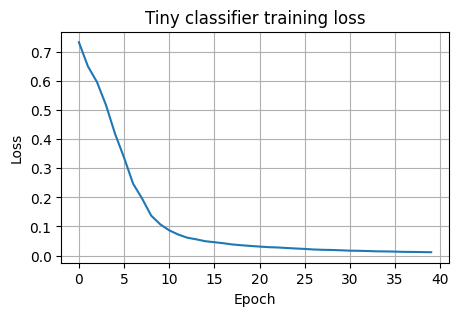

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.plot(epoch_losses)
plt.title("Tiny classifier training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Epoch 1/10 - Loss: 0.7023
Epoch 2/10 - Loss: 0.6780
Epoch 3/10 - Loss: 0.6595
Epoch 4/10 - Loss: 0.6399
Epoch 5/10 - Loss: 0.6201
Epoch 6/10 - Loss: 0.5980
Epoch 7/10 - Loss: 0.5725
Epoch 8/10 - Loss: 0.5467
Epoch 9/10 - Loss: 0.5167
Epoch 10/10 - Loss: 0.4872

Training tugadi!


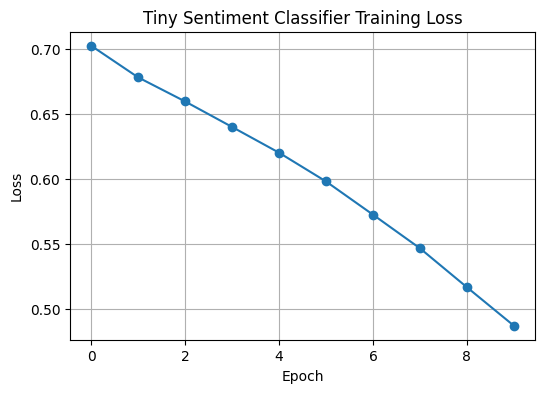

In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Model
model = TinySentimentNet(input_dim=len(vocab))

# Loss funksiyasi va optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training
num_epochs = 10
epoch_losses = []

model.train()

for epoch in range(num_epochs):
    running_loss = 0.0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(loader)
    epoch_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

print("\nTraining tugadi!")

# Loss grafigi
plt.figure(figsize=(6,4))
plt.plot(epoch_losses, marker='o')
plt.title("Tiny Sentiment Classifier Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [87]:
print("loader:", 'loader' in globals())
print("model:", 'model' in globals())
print("criterion:", 'criterion' in globals())
print("optimizer:", 'optimizer' in globals())

loader: True
model: True
criterion: True
optimizer: True


## 9. Inference

Trainingdan keyin prediction paytida gradient kerak emas. Shuning uchun `model.eval()` va `torch.no_grad()` ishlatiladi.


In [90]:
if HAS_TORCH:
    def predict_sentiment(text):
        model.eval()

        features = torch.tensor(
            vectorize(text),
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            # Forward
            logits = model(features)

            # Ehtimollar
            probabilities = torch.softmax(logits, dim=1)

            # Eng katta ehtimolli klass
            prediction = torch.argmax(probabilities, dim=1).item()

        label_name = "ijobiy" if prediction == 1 else "salbiy"
        return label_name, probabilities.squeeze(0).tolist()

    for sample in [
        "mahsulot yaxshi",
        "xizmat yomon",
        "taom juda mazali"
    ]:
        label_name, probabilities = predict_sentiment(sample)
        print(sample, "->", label_name,
              [round(p, 3) for p in probabilities])
else:
    print("Prediction demo uchun torch kerak.")


mahsulot yaxshi -> ijobiy [0.427, 0.573]
xizmat yomon -> salbiy [0.583, 0.417]
taom juda mazali -> ijobiy [0.315, 0.685]


## 10. Sequence model shape'lari

Text generation practice'da input odatda shunday bo'ladi:

`token_ids -> embedding -> LSTM -> output layer`

Quyidagi cell shape'larni ko'rsatadi. Bu LSTM ichki matematikasini emas, PyTorchdagi obyektlar qanday ulanganini ko'rsatadi.


In [89]:
if HAS_TORCH:
    batch_size = 2
    seq_len = 5
    vocab_size = 20
    embed_dim = 8
    hidden_size = 16

    token_ids = torch.randint(0, vocab_size, (batch_size, seq_len))
    embedding = nn.Embedding(vocab_size, embed_dim)
    lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)

    embedded = embedding(token_ids)
    outputs, (hidden_state, cell_state) = lstm(embedded)

    print("token_ids   :", tuple(token_ids.shape))
    print("embedded    :", tuple(embedded.shape))
    print("outputs     :", tuple(outputs.shape))
    print("hidden_state:", tuple(hidden_state.shape))
    print("cell_state  :", tuple(cell_state.shape))
else:
    print("Sequence shape demo uchun torch kerak.")


token_ids   : (2, 5)
embedded    : (2, 5, 8)
outputs     : (2, 5, 16)
hidden_state: (1, 2, 16)
cell_state  : (1, 2, 16)


## 11. Bugungi practice bilan bog'lash

Endi `d10_p9_textgen` notebookida ko'radigan char-LSTM kodi shunchaki shu PyTorch qismlarining ketma-ketligi bo'ladi:

- character IDlar;
- `nn.Embedding`;
- `nn.LSTM`;
- `nn.Linear` output;
- `CrossEntropyLoss`;
- temperatura sampling.
